In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS
from training_configuration import PATHWAYS_2A, CONTEXTS_FEATURES_2A

data = "dream_cytof"
filename = "evaluate_all_figure2a"

df = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0).assign(model=model)
    for model in PATHWAYS_2A
)

In [2]:
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

# Usual CV splits (not used, will be used once I get MDA-MB-468 runs)

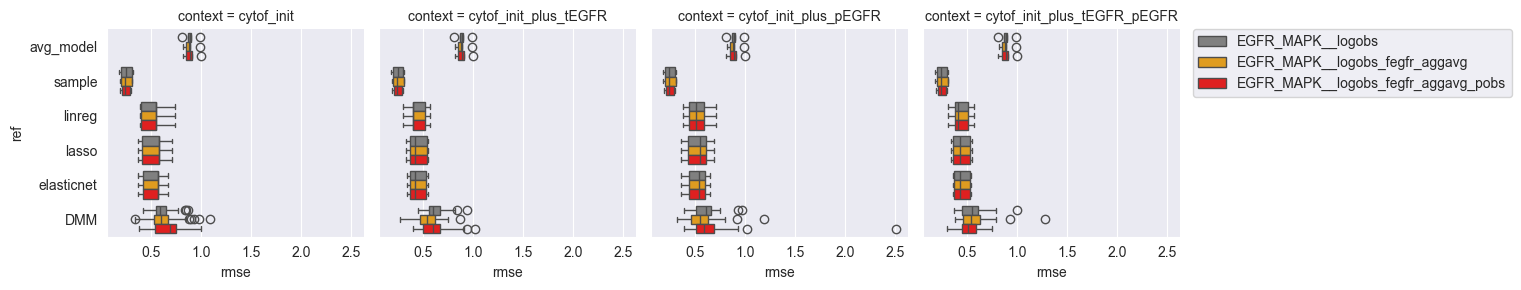

In [3]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

g = sns.FacetGrid(
    val_df,
    col="context",
    col_order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"]
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Let's zoom in on DMMs only (regressors are not affected by model choice), comparing model/context combos

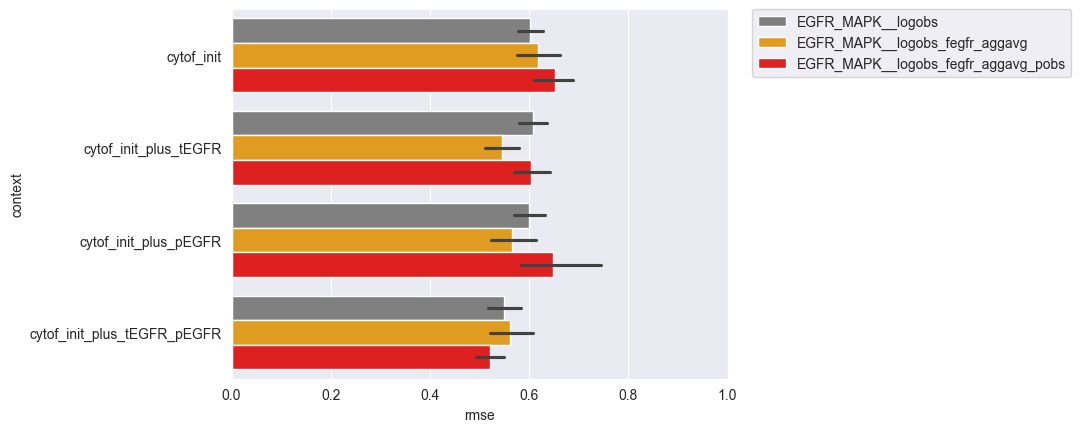

In [4]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

sns.barplot(
    val_df[val_df.ref == "DMM"],
    y="context",
    x="rmse",
    order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
    hue="model",
    palette=palette
)
plt.xlim([0, 1])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

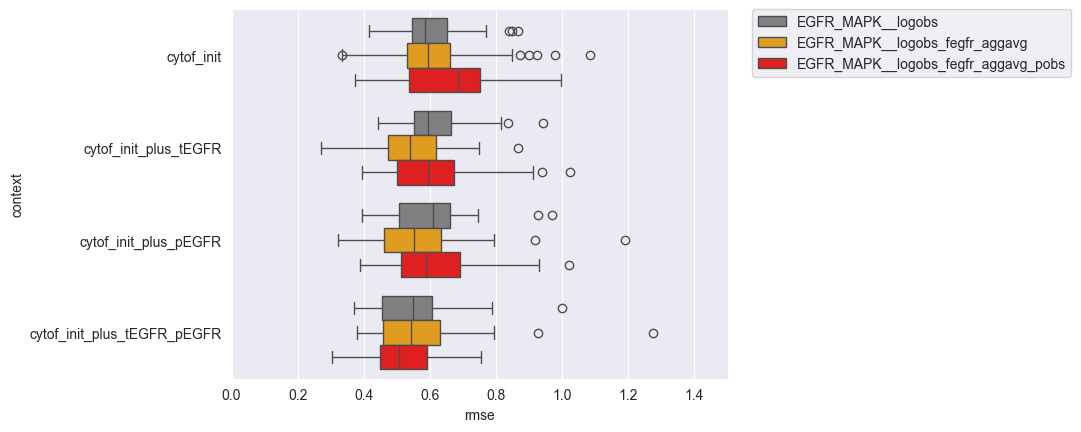

In [5]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

sns.boxplot(
    val_df[val_df.ref == "DMM"],
    y="context",
    x="rmse",
    order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
    hue="model",
    palette=palette
)
plt.xlim([0, 1.5])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Adding fegfr modification to basic cytof_init hurts - just more complexity. Adding the extra bit of `tEGFR` levels, though, helps beat the previous baseline. `pEGFR` helps, but less so, while adding both seems to help even more if adding the `pobs` modification as well. However, `pobs` seems to hurt in all other cases.

# If we look at `samples`-split, we notice we don't really get better on BT-20 (which is what we expected?), but we get better on UACC-3199. Unfortunately, we also get quite worse on EVSA-T.

(0.0, 1.0)

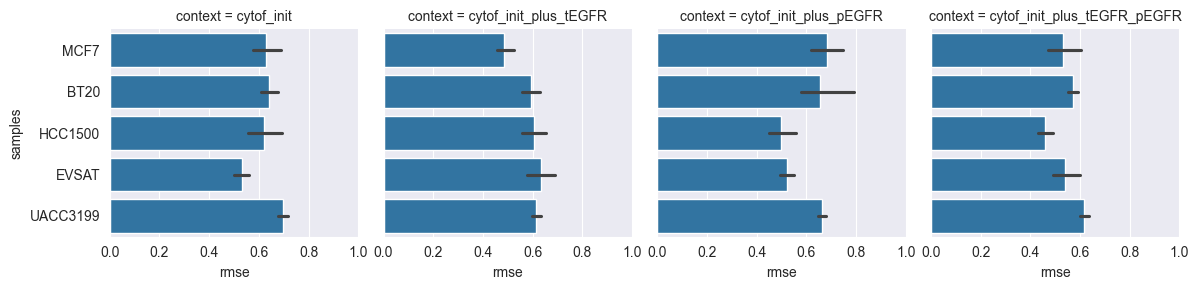

In [6]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

g = sns.FacetGrid(
    val_df[val_df.ref == "DMM"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
)

g.map_dataframe(
    sns.barplot,
    x="rmse",
    y="samples",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
)

plt.xlim([0, 1])

# Let's restrict to `__logobs_fegr_aggavg` and compare with baselines and regressors

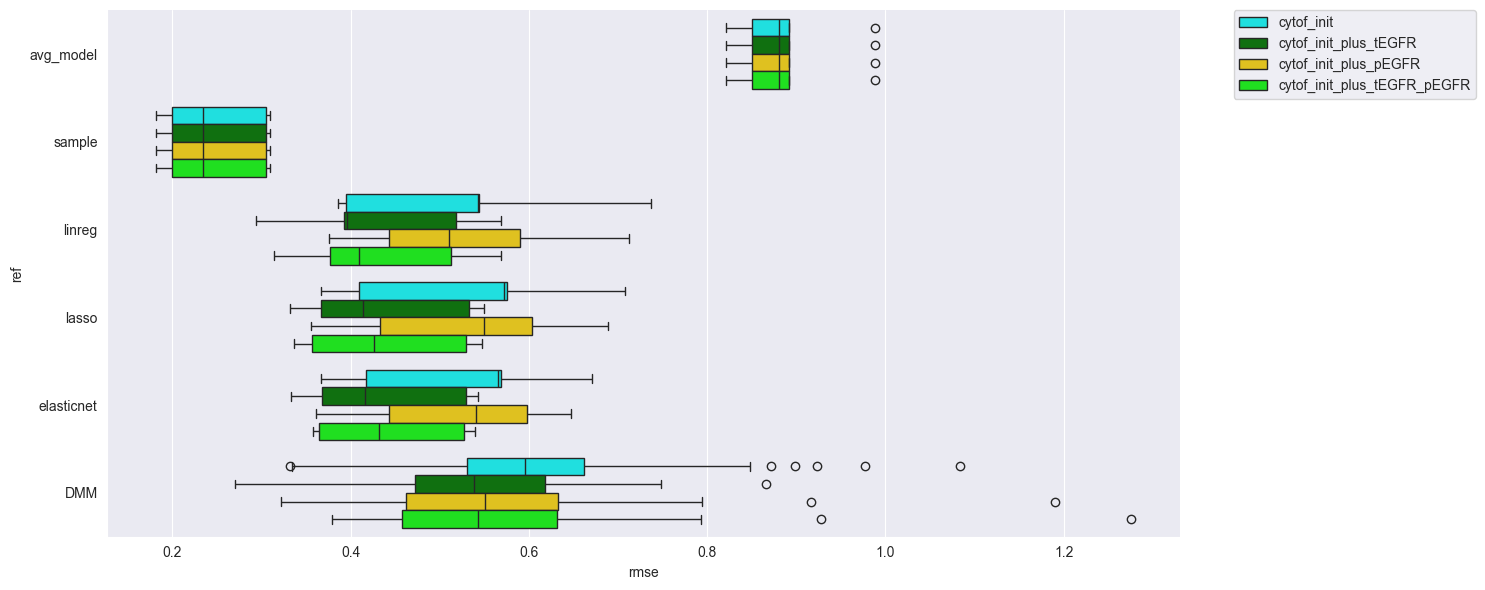

In [7]:
context_palette = {
    "cytof_init": "cyan",
    "cytof_init_plus_tEGFR": "green",
    "cytof_init_plus_pEGFR": "gold",
    "cytof_init_plus_tEGFR_pEGFR": "lime"
}

g = sns.FacetGrid(
    val_df[val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg"],
    height=6,
    aspect=2
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="context",
    hue_order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
    palette=context_palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [8]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric):
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}")

In [9]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg"]))],
    "rmse",
    "model"
)

Context: cytof_init_plus_tEGFR_pEGFR - Kruskal-Wallis H-test: H-statistic=0.01, p-value=0.9396
Context: cytof_init_plus_tEGFR - Kruskal-Wallis H-test: H-statistic=6.97, p-value=0.0083
Context: cytof_init_plus_pEGFR - Kruskal-Wallis H-test: H-statistic=2.81, p-value=0.0939
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.03, p-value=0.8686


# Clear improvement in going from `__logobs` to `__logobs_fegfr_aggavg` for `cytof_init_plus_tEGFR`

In [10]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg_pobs"]))],
    "rmse",
    "model"
)

Context: cytof_init_plus_tEGFR_pEGFR - Kruskal-Wallis H-test: H-statistic=0.88, p-value=0.3485
Context: cytof_init_plus_tEGFR - Kruskal-Wallis H-test: H-statistic=0.23, p-value=0.6343
Context: cytof_init_plus_pEGFR - Kruskal-Wallis H-test: H-statistic=0.13, p-value=0.7200
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=4.45, p-value=0.0349


But is there an improvement in going from `__logobs` with `cytof_init` to `__logobs_fegfr_aggavg` with `cytof_init_plus_tEGFR`? Or `__logobs_fegfr_aggavg_pobs` with `cytof_init_plus_tEGFR_pEGFR`? Yes, in both cases

In [11]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=6.26, p-value=0.0123, significant? True


In [12]:
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=393.0, p=0.01758


In [13]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR_pEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg_pobs") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=12.36, p-value=0.0004, significant? True


In [14]:
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=253.0, p=0.000119


# Embeddings

In [15]:
from common import basedir, evaluations_dir

embedding_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "embeddings_figure2a.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_2A
    ]
)

In [16]:
from embedding_utils import perform_pca_on_embeddings

pca_embeddings_dict = {}
for model in PATHWAYS_2A:
    print(model)
    pca_embeddings_dict[model], _ = perform_pca_on_embeddings(embedding_df[embedding_df.model == model])

EGFR_MAPK__logobs
Explained variance for cytof_init BT20: 0.9097
Explained variance for cytof_init EVSAT: 0.9659
Explained variance for cytof_init HCC1500: 0.9384
Explained variance for cytof_init MCF7: 0.9363
Explained variance for cytof_init UACC3199: 0.9776
Explained variance for cytof_init_plus_pEGFR BT20: 0.9011
Explained variance for cytof_init_plus_pEGFR EVSAT: 0.9453
Explained variance for cytof_init_plus_pEGFR HCC1500: 0.8965
Explained variance for cytof_init_plus_pEGFR MCF7: 0.8762
Explained variance for cytof_init_plus_pEGFR UACC3199: 0.8993
Explained variance for cytof_init_plus_tEGFR BT20: 0.9710
Explained variance for cytof_init_plus_tEGFR EVSAT: 0.9201
Explained variance for cytof_init_plus_tEGFR HCC1500: 0.9982
Explained variance for cytof_init_plus_tEGFR MCF7: 0.9727
Explained variance for cytof_init_plus_tEGFR UACC3199: 0.9772
Explained variance for cytof_init_plus_tEGFR_pEGFR BT20: 0.9274
Explained variance for cytof_init_plus_tEGFR_pEGFR EVSAT: 0.9610
Explained vari

In [17]:
import warnings

warnings.filterwarnings("ignore")

subtypes_marcotte = pd.read_csv(basedir / "cell_line_subtypes.txt", delimiter='\t')
subtypes_marcotte["cell_line"] = subtypes_marcotte["cell_line"].apply(lambda x: "c"+x.upper())
subtypes_marcotte.cell_line.replace("cHS578T", "cHs578T", inplace=True)
subtypes_marcotte.cell_line.replace("c600MPE", "cMPE600", inplace=True)
subtypes_marcotte.sort_values(by="cell_line", inplace=True)
subtypes_marcotte.set_index("cell_line", inplace=True)
subtypes_marcotte = subtypes_marcotte.loc[pca_embeddings_dict["EGFR_MAPK__logobs"].index.unique()]

In [18]:
for model in PATHWAYS_2A:
    pca_embeddings_dict[model]["subtype_intrinsic"] = subtypes_marcotte["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"] = pca_embeddings_dict[model]["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"].replace(["LuminalA", "LuminalB", "HER2"], "Luminal", inplace=True)
    pca_embeddings_dict[model]["luminalbasal"].replace(["CL"], "Basal", inplace=True)

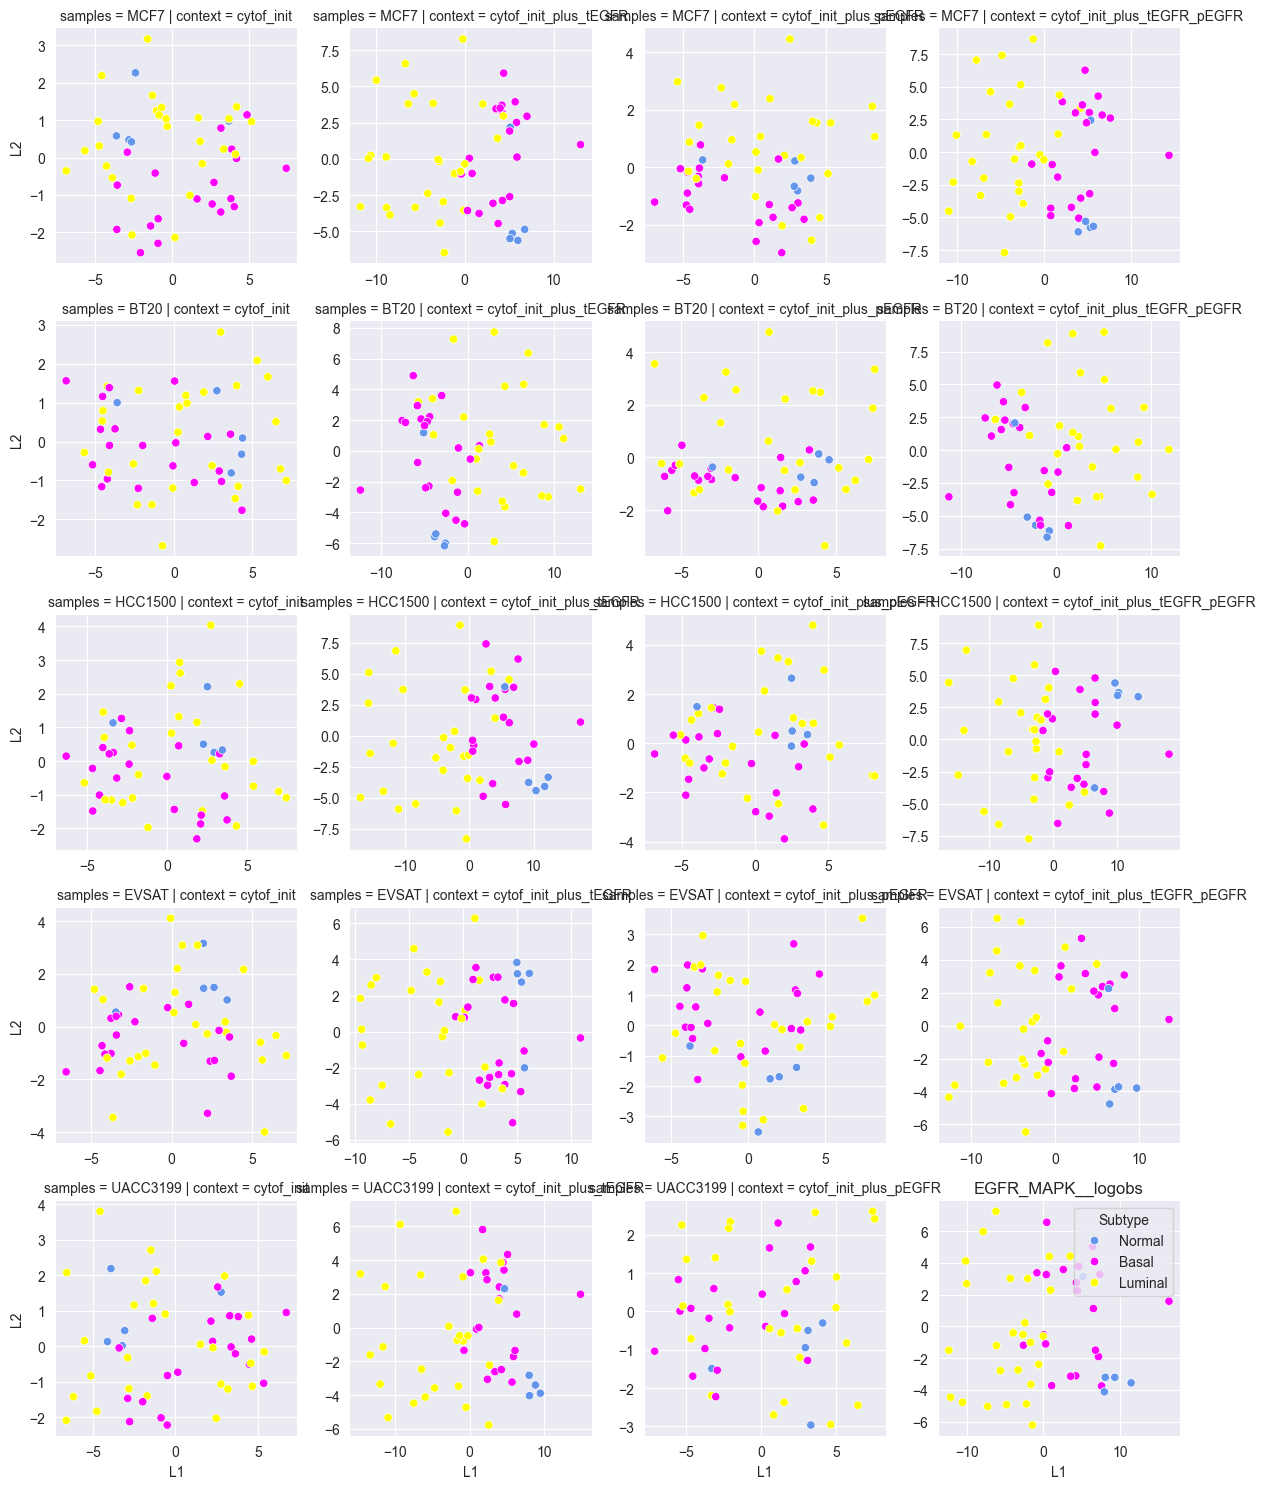

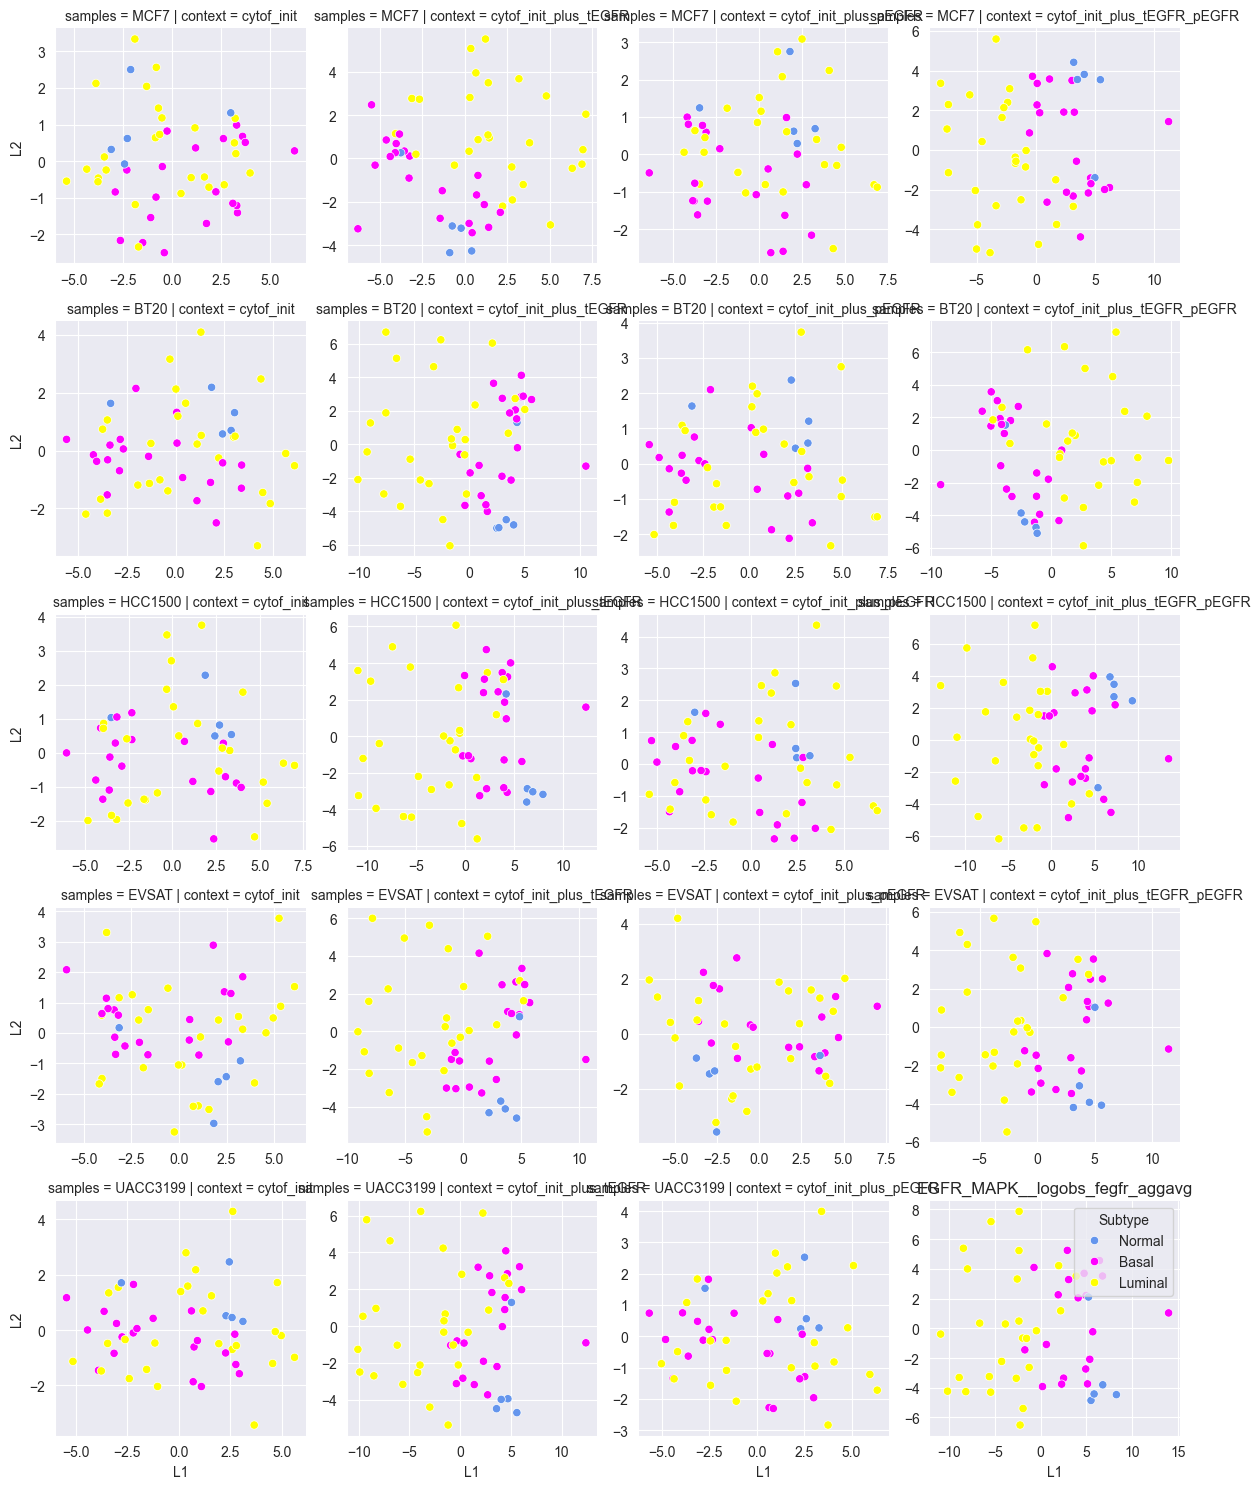

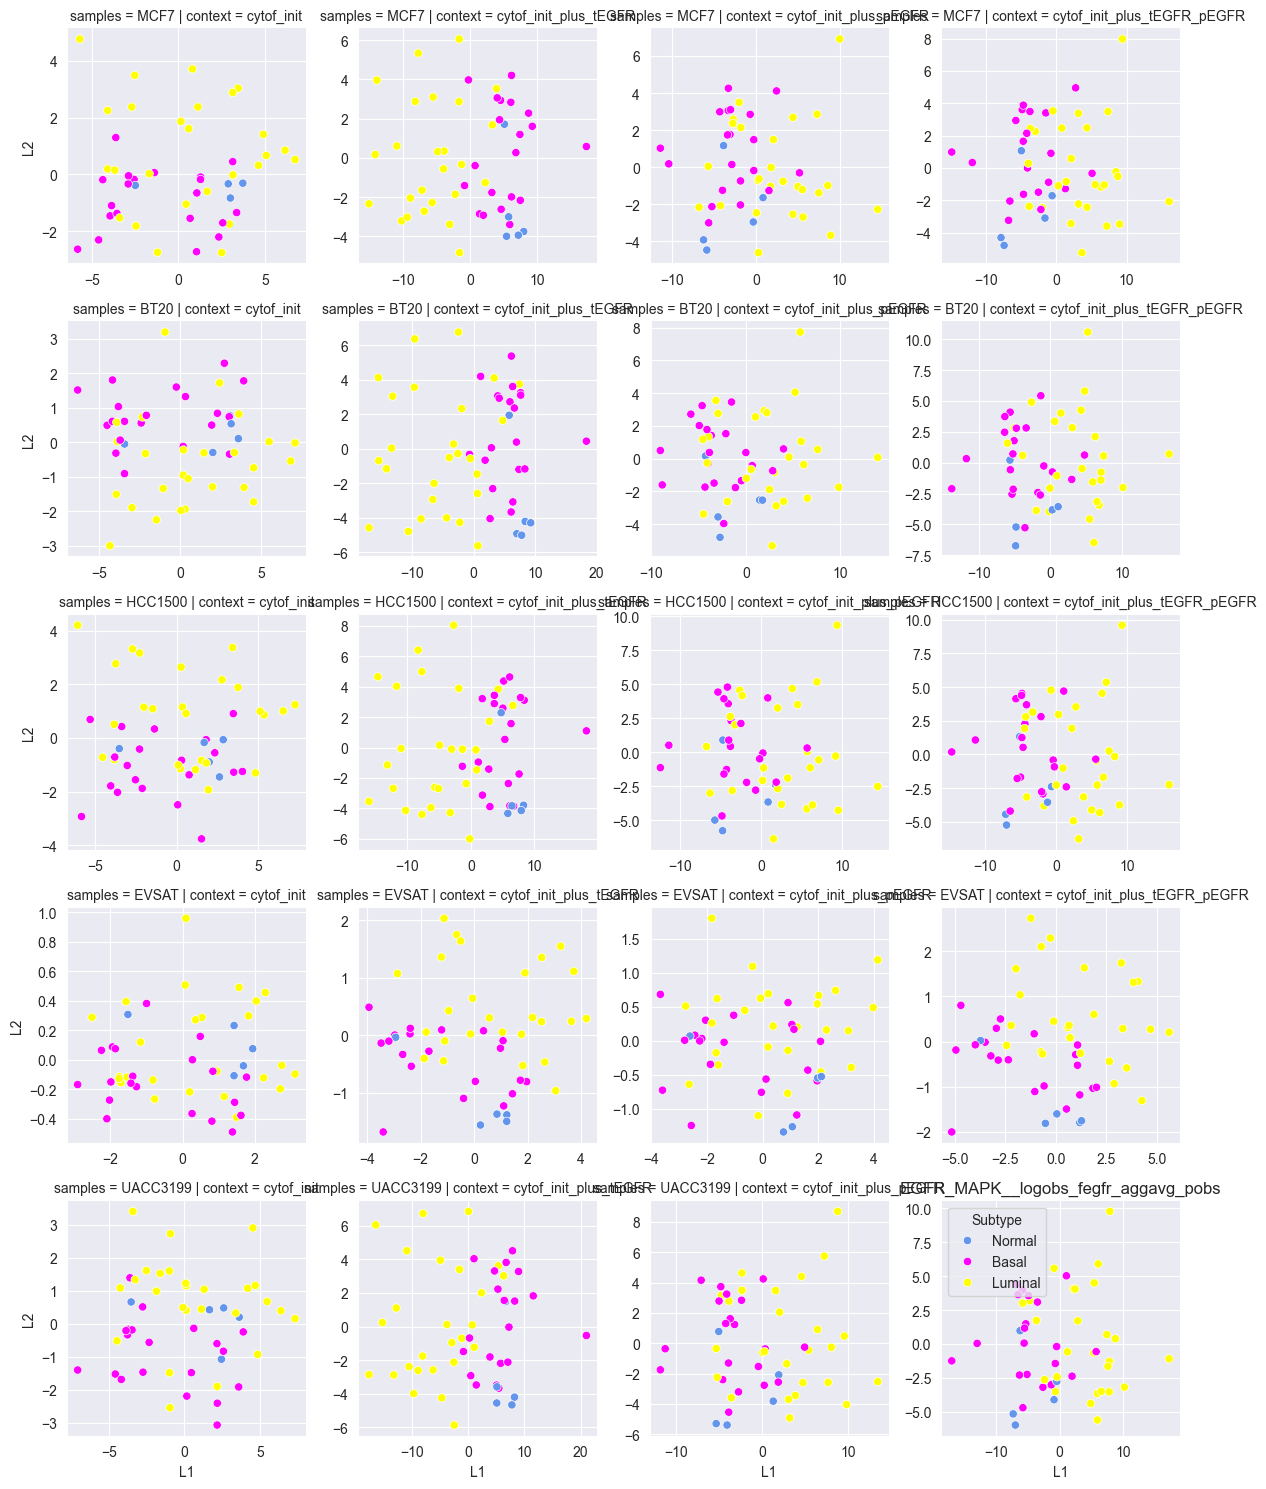

In [19]:
for model in PATHWAYS_2A:
    g = sns.FacetGrid(
        pca_embeddings_dict[model],
        row="samples",
        row_order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
        col="context",
        col_order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
        sharex=False,
        sharey=False
    )

    g.map_dataframe(
        sns.scatterplot,
        x="L1",
        y="L2",
        hue="luminalbasal",
        palette={
            "Luminal": "yellow",
            "Basal": "magenta",
            "Normal": "cornflowerblue"
        }
    )

    plt.title(model)

    plt.legend(title="Subtype")
    plt.show()

EGFR_MAPK__logobs cytof_init
0.31686507936507935


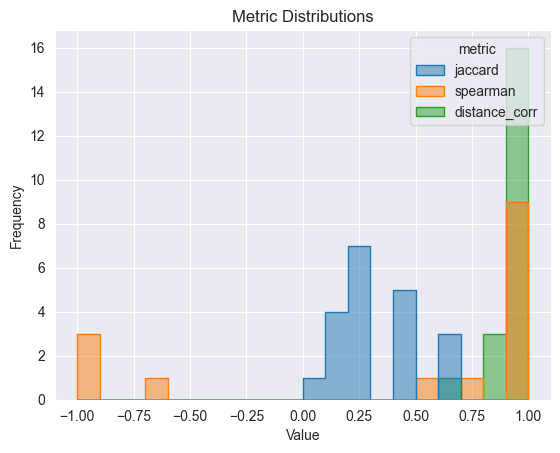

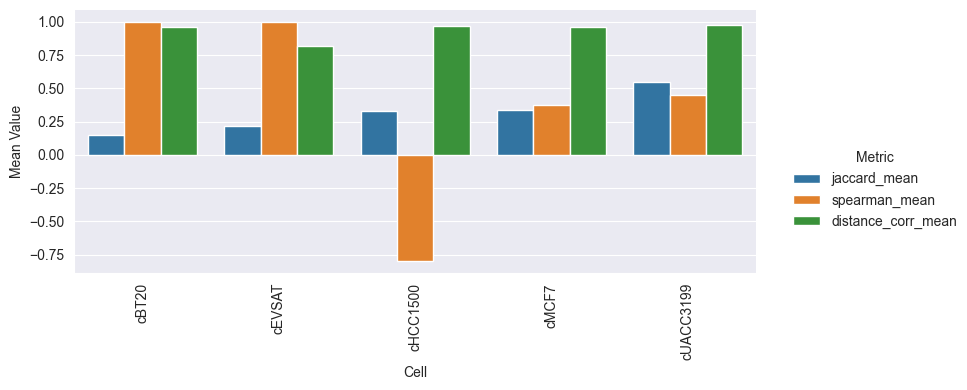

EGFR_MAPK__logobs cytof_init_plus_tEGFR
0.5517857142857142


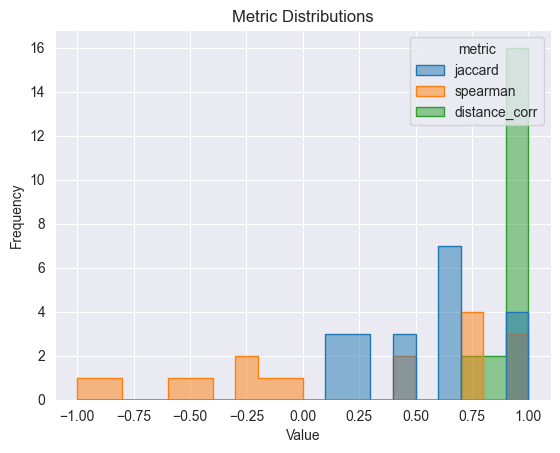

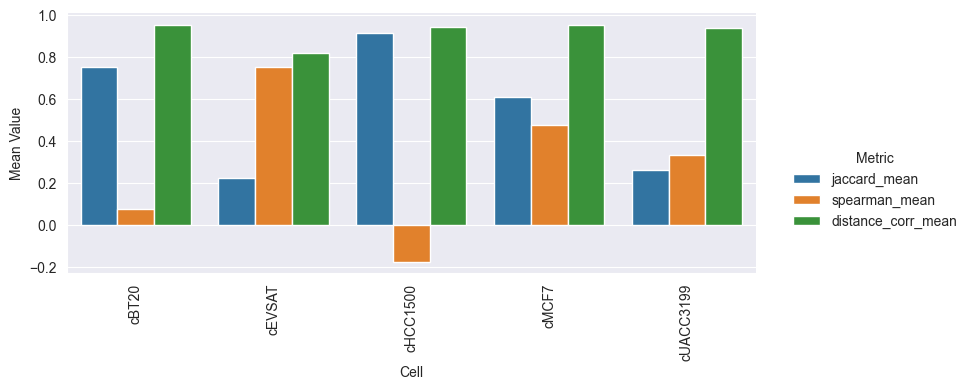

EGFR_MAPK__logobs cytof_init_plus_pEGFR
0.27420634920634923


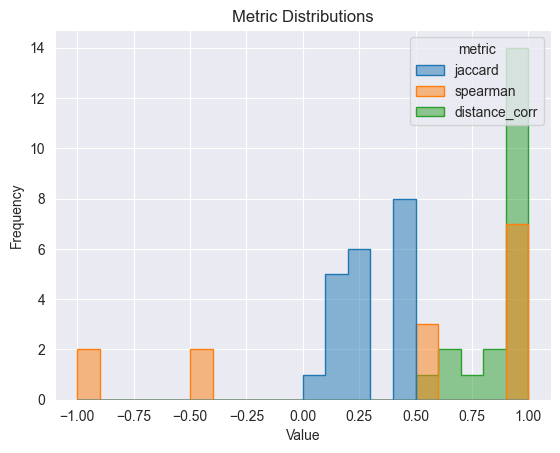

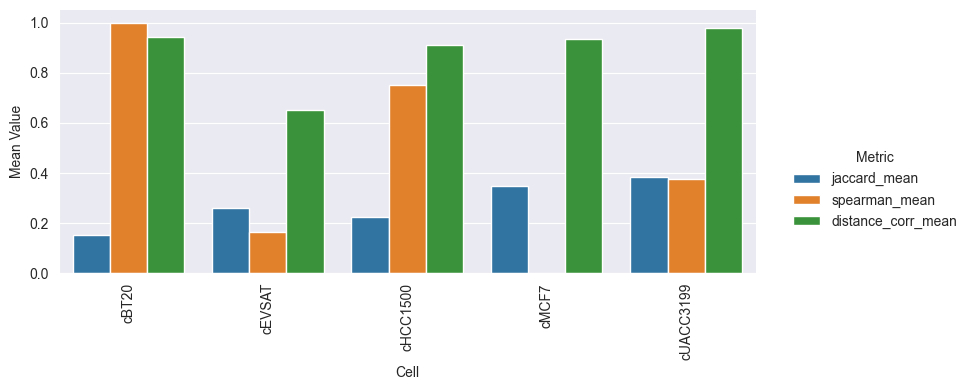

EGFR_MAPK__logobs cytof_init_plus_tEGFR_pEGFR
0.46507936507936504


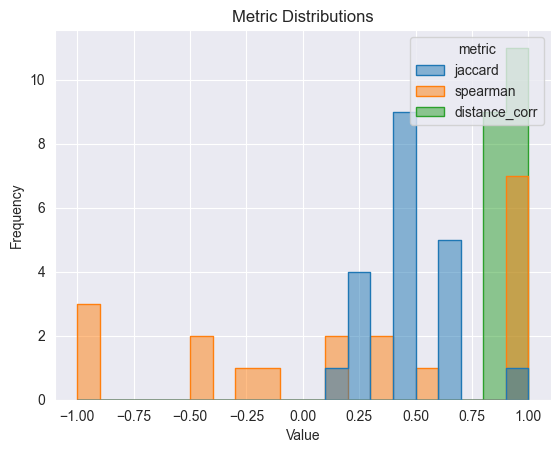

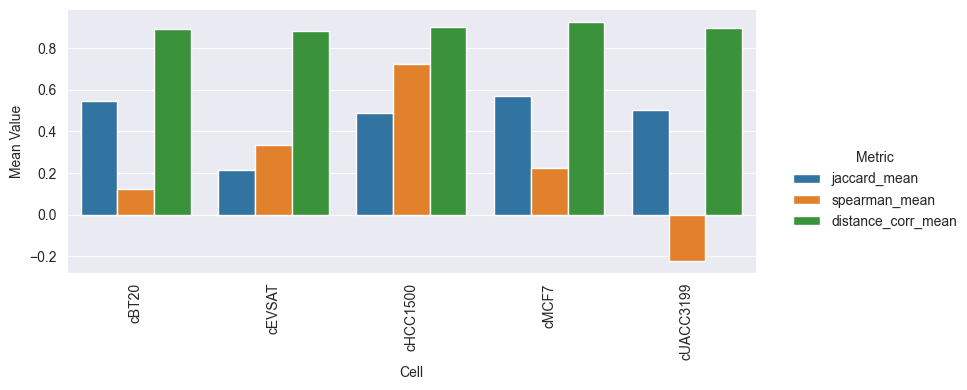

EGFR_MAPK__logobs_fegfr_aggavg cytof_init
0.4442460317460317


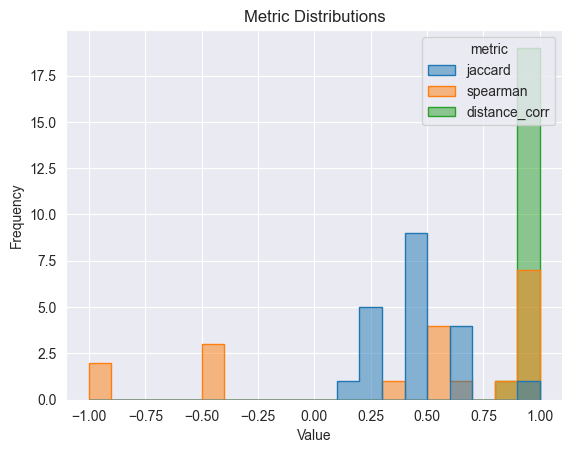

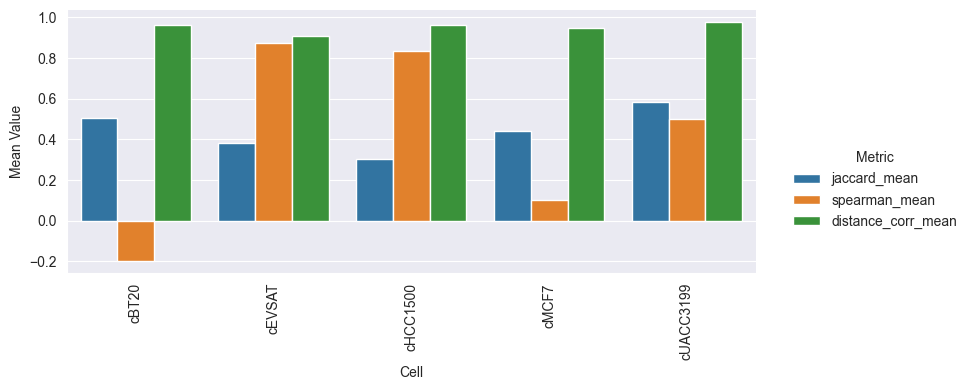

EGFR_MAPK__logobs_fegfr_aggavg cytof_init_plus_tEGFR
0.5571428571428572


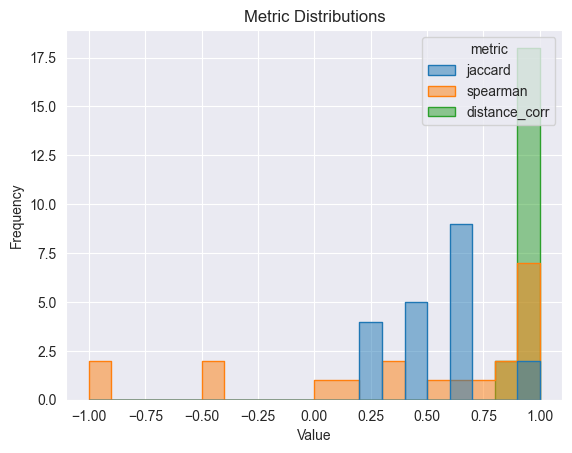

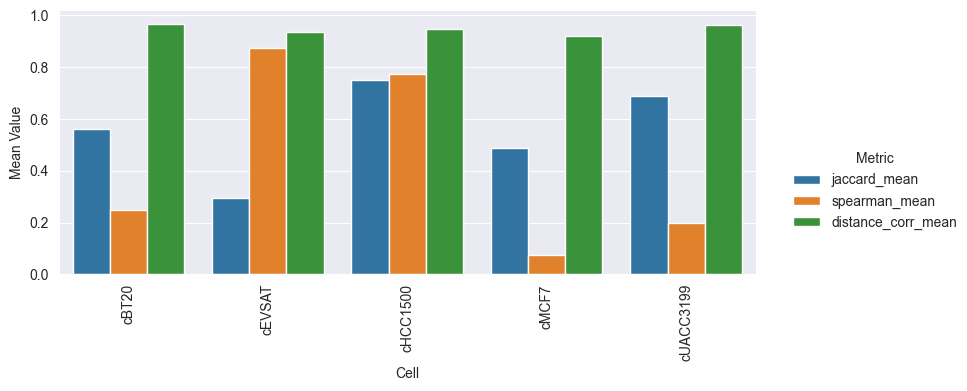

EGFR_MAPK__logobs_fegfr_aggavg cytof_init_plus_pEGFR
0.4561507936507937


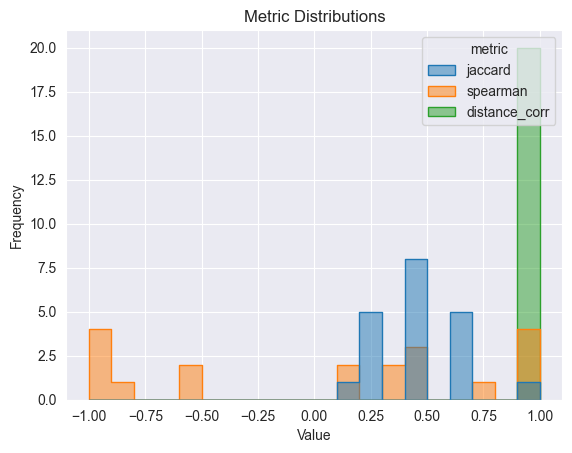

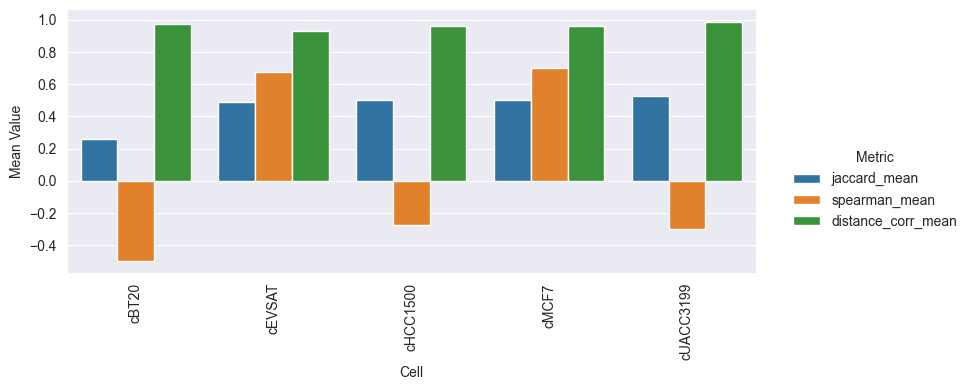

EGFR_MAPK__logobs_fegfr_aggavg cytof_init_plus_tEGFR_pEGFR
0.5007936507936508


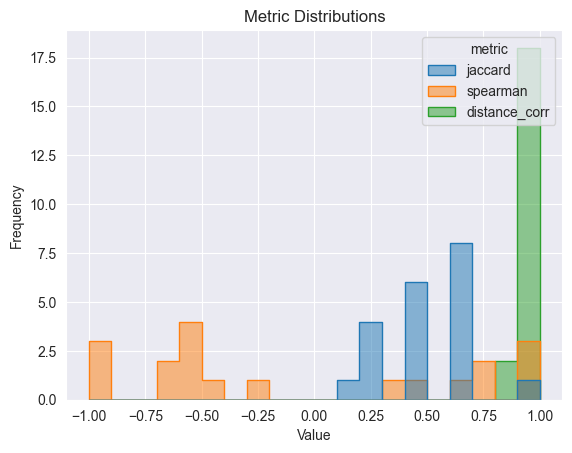

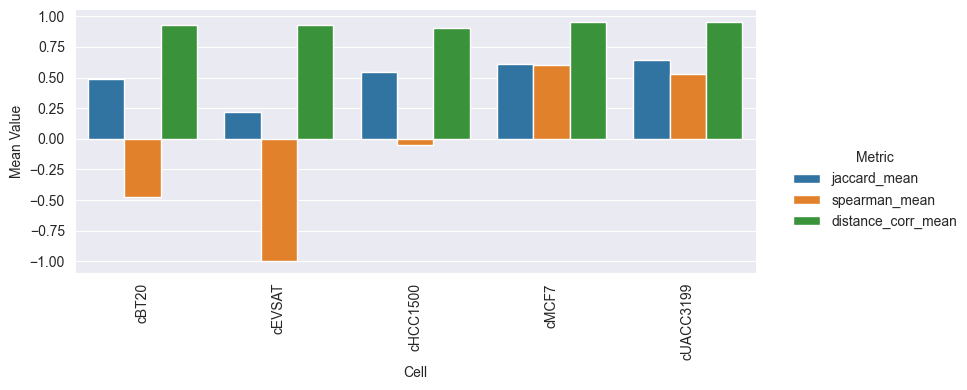

EGFR_MAPK__logobs_fegfr_aggavg_pobs cytof_init
0.3825396825396825


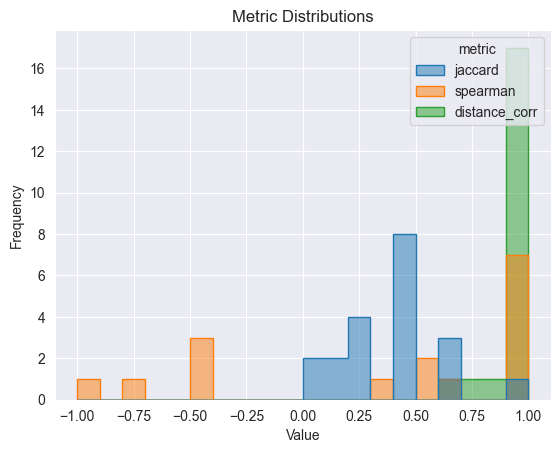

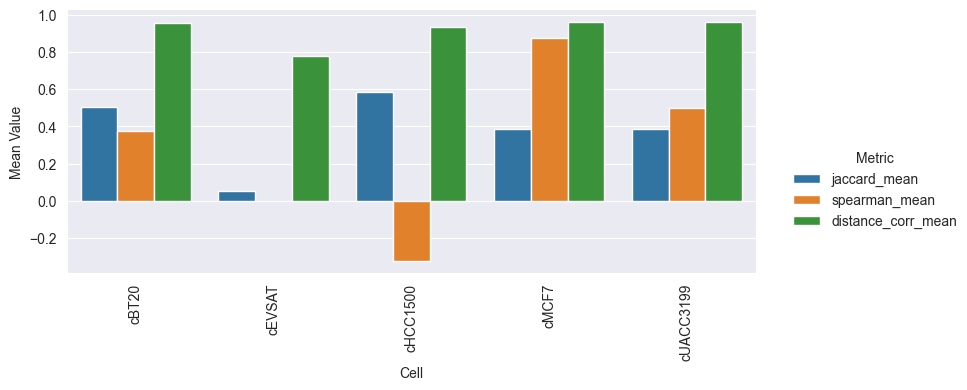

EGFR_MAPK__logobs_fegfr_aggavg_pobs cytof_init_plus_tEGFR
0.5125


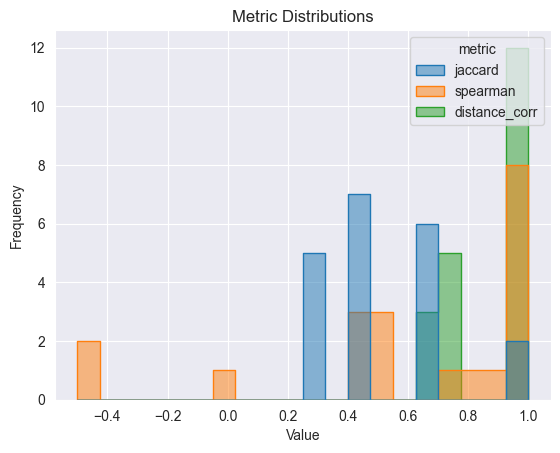

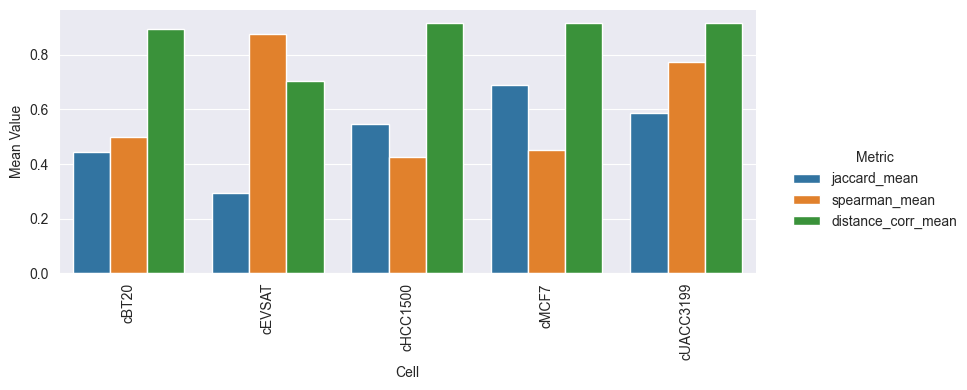

EGFR_MAPK__logobs_fegfr_aggavg_pobs cytof_init_plus_pEGFR
0.392063492063492


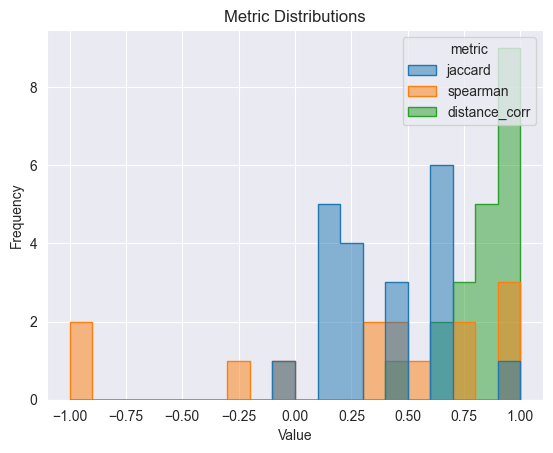

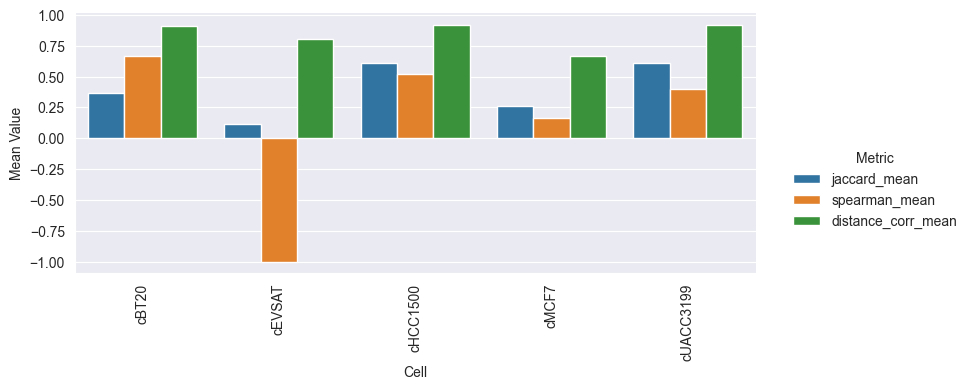

EGFR_MAPK__logobs_fegfr_aggavg_pobs cytof_init_plus_tEGFR_pEGFR
0.5499999999999999


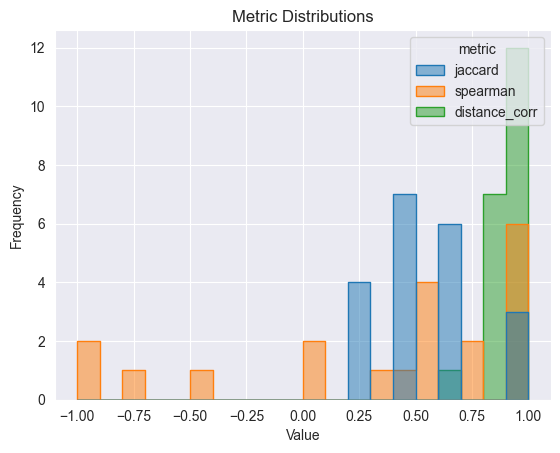

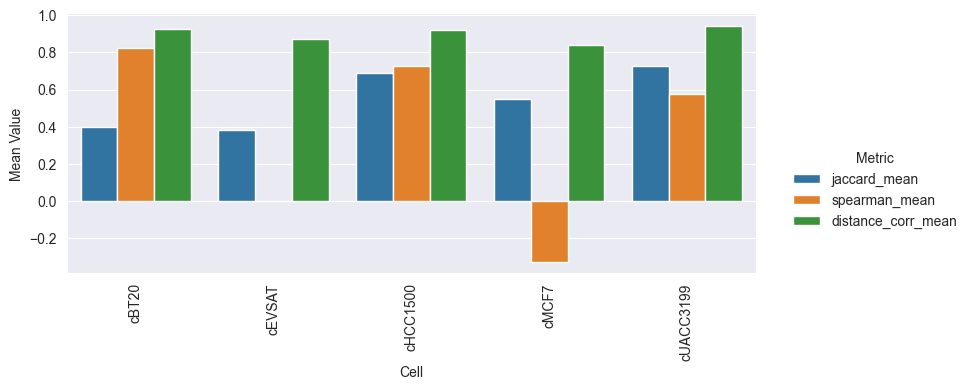

In [20]:
import itertools as itt
from embedding_consistency import *
from training_configuration import CONTEXTS_FEATURES_2A

# Compute per (split vs other_split) comparisons for each validation cell
splits = ["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"]

summaries = []
for model, (context, _) in itt.product(PATHWAYS_2A, CONTEXTS_FEATURES_2A):
    print(model, context)
    per_pair = compute_validation_neighborhood_consistency(
        {split: pca_embeddings_dict[model][(pca_embeddings_dict[model]["samples"] == split) & (pca_embeddings_dict[model].context == context)][["L1", "L2"]] for split in splits},
        {split: "c"+split for split in splits},
        n_neighbors=5,      # set N here
        metric="euclidean",  # or "cosine"
    )

    # Summaries per cell
    summary = summarize_consistency(per_pair)
    print(summary.jaccard_mean.mean())
    summaries.append(summary.assign(model=model, context=context))

    plot_distribution(per_pair)
    plot_per_cell_summary(summary)

overall_summary = pd.concat(summaries)

In [21]:
overall_summary.groupby(["model", "context"]).agg({"jaccard_mean": "mean", "spearman_mean": "mean", "distance_corr_mean": "mean"})

jaccard_mean  \
model                               context                                     
EGFR_MAPK__logobs                   cytof_init                       0.316865   
                                    cytof_init_plus_pEGFR            0.274206   
                                    cytof_init_plus_tEGFR            0.551786   
                                    cytof_init_plus_tEGFR_pEGFR      0.465079   
EGFR_MAPK__logobs_fegfr_aggavg      cytof_init                       0.444246   
                                    cytof_init_plus_pEGFR            0.456151   
                                    cytof_init_plus_tEGFR            0.557143   
                                    cytof_init_plus_tEGFR_pEGFR      0.500794   
EGFR_MAPK__logobs_fegfr_aggavg_pobs cytof_init                       0.382540   
                                    cytof_init_plus_pEGFR            0.392063   
                                    cytof_init_plus_tEGFR            0.512500   
                                    cytof_init_plus_tEGFR_pEGFR      0.550000   

                                                                 spearman_mean  \
model                               context                                      
EGFR_MAPK__logobs                   cytof_init                        0.405000   
                                    cytof_init_plus_pEGFR             0.458333   
                                    cytof_init_plus_tEGFR             0.291667   
                                    cytof_init_plus_tEGFR_pEGFR       0.236667   
EGFR_MAPK__logobs_fegfr_aggavg      cytof_init                        0.421667   
                                    cytof_init_plus_pEGFR             0.060000   
                                    cytof_init_plus_tEGFR             0.435000   
                                    cytof_init_plus_tEGFR_pEGFR      -0.080000   
EGFR_MAPK__logobs_fegfr_aggavg_pobs cytof_init                        0.356250   
                                    cytof_init_plus_pEGFR             0.151667   
                                    cytof_init_plus_tEGFR             0.605000   
                                    cytof_init_plus_tEGFR_pEGFR       0.360000   

                                                                 distance_corr_mean  
model                               context                                          
EGFR_MAPK__logobs                   cytof_init                             0.936955  
                                    cytof_init_plus_pEGFR                  0.884154  
                                    cytof_init_plus_tEGFR                  0.920500  
                                    cytof_init_plus_tEGFR_pEGFR            0.900240  
EGFR_MAPK__logobs_fegfr_aggavg      cytof_init                             0.951984  
                                    cytof_init_plus_pEGFR                  0.963037  
                                    cytof_init_plus_tEGFR                  0.946882  
                                    cytof_init_plus_tEGFR_pEGFR            0.933251  
EGFR_MAPK__logobs_fegfr_aggavg_pobs cytof_init                             0.917341  
                                    cytof_init_plus_pEGFR                  0.844326  
                                    cytof_init_plus_tEGFR                  0.870046  
                                    cytof_init_plus_tEGFR_pEGFR            0.901152

# Top 3 consistent settings: cytof_init_plus_tEGFR with EGFR_MAPK__logobs_fegfr_aggavg (second best performing), cytof_init_plus_tEGFR_pEGFR with EGFR_MAPK__logobs_fegfr_aggavg_pobs (best performing), cytof_init_plus_tEGFR with EGFR_MAPK__logobs (VERY SURPRISING). Nonetheless, we see that the inclusion of tEGFR features is consistent in all top 3. If we combine this with performance (RMSE scores), then we are left with choosing between fegfr_aggavg_pobs with both tEGFR and pEGFR or fegfr_aggavg with tEGFR only. fegfr_aggavg with tEGFR only gets less input info AND it also displays higher mean Spearman correlation, meaning that when neighbours are the same between val and train, they also appear in more consistent distance-wise ordering/ranking.

# Trying to make sense of parameter deviations - PCA-ing across jobs/multistarts and investigating differences between train/val on val cell-lines

In [22]:
import itertools as itt
from common import evaluations_dir
from sklearn.decomposition import PCA

par_dev_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "param_devs_figure2a.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_2A
    ]
)
par_dev_df = par_dev_df[par_dev_df.samples.isin(["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"])]
par_dev_df["EGFR_eq"] = par_dev_df["EGFR_eq"].fillna(1)

not_param_cols = [
    "cell_line", "context", "model", "features", "samples", "dataset", "l1reg_inflater_output", "inflater_output_reg_epoch", "recon_loss", "inflater_bound", "n_epoch", "job"
]
param_cols = [col for col in par_dev_df.columns if col not in not_param_cols]

median_par_dev_df = par_dev_df.groupby(["context", "features", "cell_line", "samples"])[param_cols].median().reset_index()


def pca_param_devs(par_dev_df):
    results_dfs = []
    for ctxt, split in itt.product(par_dev_df.context.unique(), par_dev_df.samples.unique()):
        sub_df = par_dev_df[(par_dev_df.context == ctxt) & (par_dev_df.samples == split)]
        # Compute median across job/multistart
        sub_df = sub_df.groupby(["context", "samples", "cell_line"])[param_cols].median().reset_index()
        sub_df.set_index("cell_line", inplace=True)
        pca = PCA(n_components=2)
        temp_res = pd.DataFrame(
            pca.fit_transform(sub_df[param_cols]),
            sub_df.index,
            columns=["PC1", "PC2"]
        ).assign(context=ctxt, samples=split, pca_expl = pca.explained_variance_ratio_.sum())
        results_dfs.append(temp_res)
    return pd.concat(results_dfs)


pca_param_df = pd.concat(
    [
        pca_param_devs(par_dev_df[par_dev_df.model == model]).assign(model=model)
        for model in PATHWAYS_2A
    ]
)

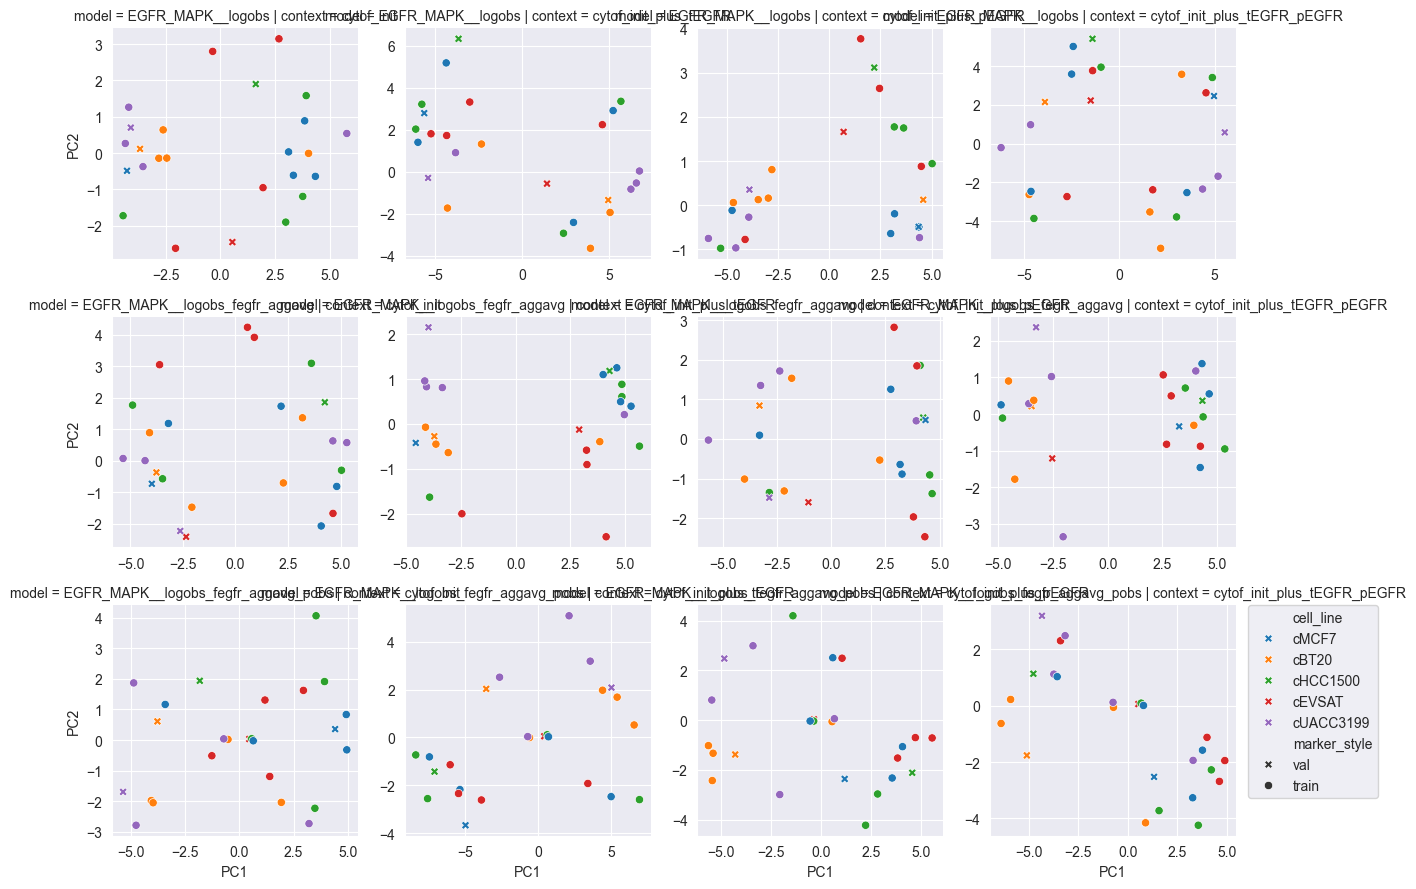

In [23]:
# Add a new column for marker style
pca_param_df["marker_style"] = pca_param_df.apply(
    lambda row: "val" if row.name[1:] == row["samples"] else "train",
    axis=1
)

# Define marker mapping
marker_dict = {"val": "X", "train": "o"}  # X for validation, circle otherwise

g = sns.FacetGrid(
    pca_param_df[pca_param_df.index.isin(["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cUACC3199"])],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_fegfr_aggavg_pobs"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="PC1",
    y="PC2",
    hue="cell_line",
    style="marker_style",        # use the new column for marker
    markers=marker_dict,         # assign specific markers
    hue_order=["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cUACC3199"]
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()